In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")
np.random.seed(42)

# realistic student dataset
n = 300
df = pd.DataFrame({
    "study_hours"  : np.random.normal(5, 2, n).clip(0, 12),
    "marks"        : np.random.normal(65, 12, n).clip(0, 100),
    "age"          : np.random.randint(18, 30, n),
    "fees_paid"    : np.random.exponential(50000, n),
    "gender"       : np.random.choice(["Male","Female"], n, p=[0.55,0.45]),
    "grade"        : np.random.choice(["A","B","C","D"], n, p=[0.2,0.4,0.3,0.1]),
    "city"         : np.random.choice(["Mumbai","Delhi","Surat","Pune"], n),
    "passed"       : np.random.choice(["Yes","No"], n, p=[0.75,0.25])
})

# make marks correlated with study hours (realistic)
df["marks"] = (df["study_hours"] * 6 +
               np.random.normal(30, 8, n)).clip(0, 100)

print(df.shape)
print(df.head())

(300, 8)
   study_hours      marks  age      fees_paid  gender grade    city passed
0     5.993428  54.938964   21   17628.576980    Male     A   Delhi     No
1     4.723471  43.476892   29   41782.176535  Female     C   Delhi    Yes
2     6.295377  74.423057   19   32317.989335    Male     B  Mumbai    Yes
3     8.046060  76.824532   28   54483.296155  Female     B  Mumbai     No
4     4.531693  63.366332   20  138096.082376  Female     A   Surat    Yes


# Type 1  : Numerical vs Numerical

In [3]:
# pearson correlation between two columns
r, p_value = stats.pearsonr(df["study_hours"], df["marks"])
print(f"\nstudy_hours vs marks:")
print(f"  Correlation (r) : {r:.4f}")
print(f"  P-value         : {p_value:.6f}")
print(f"  Significant?    : {'Yes ' if p_value < 0.05 else 'No '}")

r2, p2 = stats.pearsonr(df["age"], df["marks"])
print(f"\nage vs marks:")
print(f"  Correlation (r) : {r2:.4f}")
print(f"  P-value         : {p2:.6f}")
print(f"  Significant?    : {'Yes ' if p2 < 0.05 else 'No '}")

# full correlation matrix (all numerical columns at once)
print("\nFull Correlation Matrix:")
print(df[["study_hours","marks","age","fees_paid"]].corr().round(2))


study_hours vs marks:
  Correlation (r) : 0.8003
  P-value         : 0.000000
  Significant?    : Yes 

age vs marks:
  Correlation (r) : -0.0494
  P-value         : 0.393878
  Significant?    : No 

Full Correlation Matrix:
             study_hours  marks   age  fees_paid
study_hours         1.00   0.80  0.01      -0.08
marks               0.80   1.00 -0.05      -0.04
age                 0.01  -0.05  1.00       0.02
fees_paid          -0.08  -0.04  0.02       1.00


### Plot 1 — Scatter Plot (study_hours vs marks)


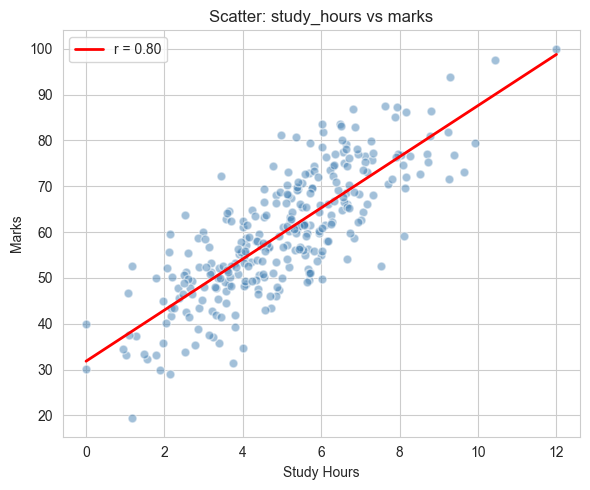

In [14]:
plt.figure(figsize=(6, 5))

plt.scatter(df["study_hours"], df["marks"],
            alpha=0.5, color='steelblue', edgecolors='white', s=40)

m, b = np.polyfit(df["study_hours"], df["marks"], 1)
x_line = np.linspace(df["study_hours"].min(), df["study_hours"].max(), 100)
plt.plot(x_line, m*x_line+b, color='red', linewidth=2, label=f'r = {r:.2f}')

plt.title("Scatter: study_hours vs marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()
plt.tight_layout()
plt.show()

### Plot 2 — Scatter Plot (age vs marks, weak relationship)


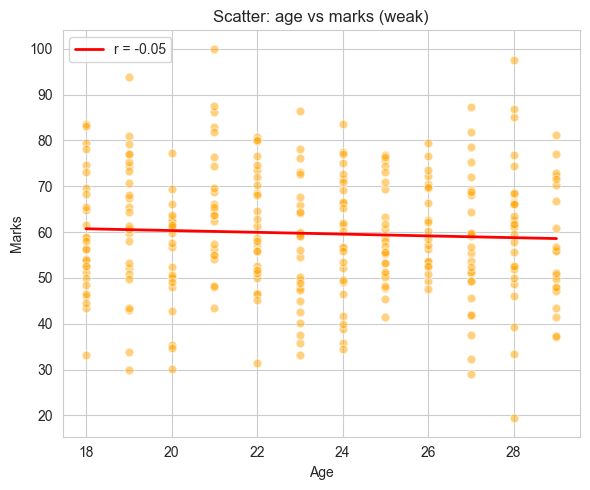

In [13]:
plt.figure(figsize=(6, 5))

plt.scatter(df["age"], df["marks"],
            alpha=0.5, color='orange', edgecolors='white', s=40)

m2, b2 = np.polyfit(df["age"], df["marks"], 1)
x_line2 = np.linspace(df["age"].min(), df["age"].max(), 100)
plt.plot(x_line2, m2*x_line2+b2, color='red', linewidth=2, label=f'r = {r2:.2f}')

plt.title("Scatter: age vs marks (weak)")
plt.xlabel("Age")
plt.ylabel("Marks")
plt.legend()
plt.tight_layout()
plt.show()

### Plot 3 — Correlation Heatmap


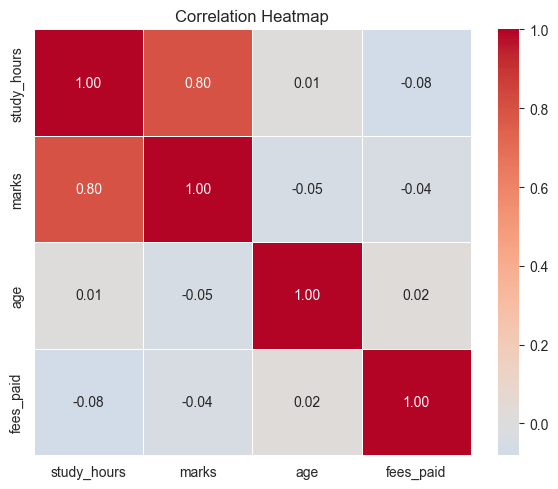

In [12]:
plt.figure(figsize=(6, 5))

corr_matrix = df[["study_hours", "marks", "age", "fees_paid"]].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Type 2 : Categorical vs Categorical

In [16]:
# raw counts
cross_tab = pd.crosstab(df["grade"], df["gender"])
print("\nCross Tab (counts):")
print(cross_tab)

# percentages
cross_tab_pct = pd.crosstab(df["grade"], df["gender"], normalize='index').mul(100).round(1)
print("\nCross Tab (row %):")
print(cross_tab_pct)

# ── CHI-SQUARE TEST ───────────────────────────────────────
chi2, p, dof, expected = chi2_contingency(cross_tab)
print(f"\nChi-Square Test: grade vs gender")
print(f"  Chi2 statistic : {chi2:.4f}")
print(f"  P-value        : {p:.4f}")
print(f"  Degrees of free: {dof}")
print(f"  Significant?   : {'Yes ' if p < 0.05 else ''}")

# ── ANOTHER PAIR ──────────────────────────────────────────
cross_tab2 = pd.crosstab(df["grade"], df["passed"])
chi2_2, p2, _, _ = chi2_contingency(cross_tab2)
print(f"\nChi-Square Test: grade vs passed")
print(f"  P-value        : {p2:.4f}")
print(f"  Significant?   : {'Yes ' if p2 < 0.05 else 'No '}")


Cross Tab (counts):
gender  Female  Male
grade               
A           30    37
B           49    58
C           48    47
D           12    19

Cross Tab (row %):
gender  Female  Male
grade               
A         44.8  55.2
B         45.8  54.2
C         50.5  49.5
D         38.7  61.3

Chi-Square Test: grade vs gender
  Chi2 statistic : 1.4741
  P-value        : 0.6883
  Degrees of free: 3
  Significant?   : 

Chi-Square Test: grade vs passed
  P-value        : 0.5553
  Significant?   : No 


### Plot 1 : Grouped bar chart

<Figure size 800x600 with 0 Axes>

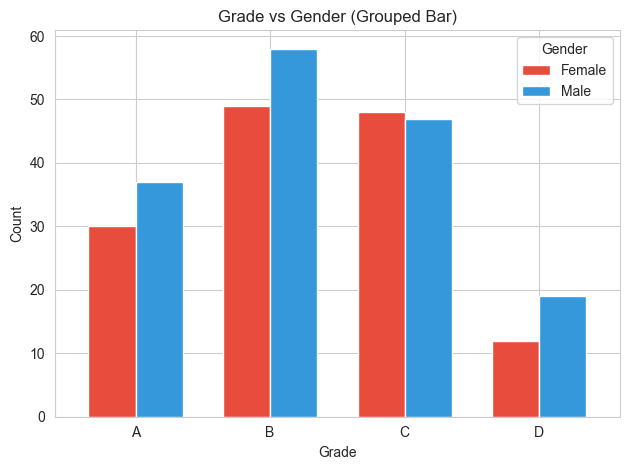

In [17]:
plt.figure(figsize=(8, 6))

cross_tab.plot(kind='bar',
               color=['#e74c3c', '#3498db'],
               edgecolor='white',
               width=0.7)

plt.title("Grade vs Gender (Grouped Bar)")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

### Plot 2 — Stacked Bar (Proportions)


<Figure size 800x600 with 0 Axes>

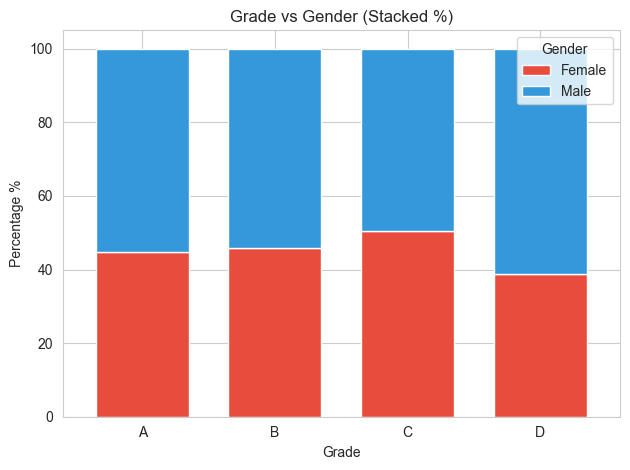

In [18]:
plt.figure(figsize=(8, 6))

cross_tab_pct.plot(kind='bar',
                   stacked=True,
                   color=['#e74c3c', '#3498db'],
                   edgecolor='white',
                   width=0.7)

plt.title("Grade vs Gender (Stacked %)")
plt.xlabel("Grade")
plt.ylabel("Percentage %")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig("stacked_bar_grade_vs_gender.png", dpi=150)
plt.show()

# Type 3 : Numerical vs Categorical

In [20]:
# ── GROUP STATISTICS ─────────────────────────────────────
print("=" * 50)
print("NUMERICAL vs CATEGORICAL")
print("=" * 50)

# mean marks per grade
print("\nMean marks per grade:")
print(df.groupby("grade")["marks"].mean().round(2))

# full stats per gender
print("\nMarks stats by gender:")
print(df.groupby("gender")["marks"].agg(
    ["mean","median","std","min","max","count"]
).round(2))

# ── ANOVA TEST ────────────────────────────────────────────
# tests if means of groups are significantly different
groups = [group["marks"].values for _, group in df.groupby("grade")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\nANOVA Test: marks across grades")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  P-value     : {p_anova:.6f}")
print(f"  Significant?: {'Yes  — marks differ by grade' if p_anova < 0.05 else 'No '}")

# ── T-TEST ────────────────────────────────────────────────
# tests if means of exactly 2 groups are different
male_marks   = df[df["gender"]=="Male"]["marks"]
female_marks = df[df["gender"]=="Female"]["marks"]
t_stat, p_ttest = stats.ttest_ind(male_marks, female_marks)
print(f"\nT-Test: marks by gender")
print(f"  T-statistic : {t_stat:.4f}")
print(f"  P-value     : {p_ttest:.4f}")
print(f"  Significant?: {'Yes ' if p_ttest < 0.05 else 'No '}")

NUMERICAL vs CATEGORICAL

Mean marks per grade:
grade
A    58.25
B    60.87
C    59.91
D    58.01
Name: marks, dtype: float64

Marks stats by gender:
         mean  median    std    min     max  count
gender                                            
Female  58.85   57.87  14.20  19.37  100.00    139
Male    60.40   60.58  12.96  29.03   93.95    161

ANOVA Test: marks across grades
  F-statistic : 0.6903
  P-value     : 0.558564
  Significant?: No 

T-Test: marks by gender
  T-statistic : 0.9854
  P-value     : 0.3252
  Significant?: No 


### Plot 1 : Box Plot

<Figure size 600x600 with 0 Axes>

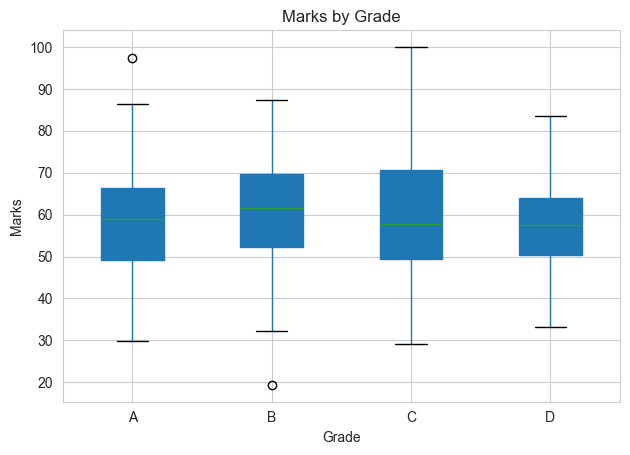

In [21]:
plt.figure(figsize=(6, 6))

df.boxplot(column="marks", by="grade",
           patch_artist=True)

plt.title("Marks by Grade")
plt.suptitle("")          # removes default pandas suptitle
plt.xlabel("Grade")
plt.ylabel("Marks")
plt.tight_layout()
plt.savefig("boxplot_marks_by_grade.png", dpi=150)
plt.show()

### Plot 2 : Violin Plot

C:\Users\kinar\AppData\Local\Temp\ipykernel_27856\4284027579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,


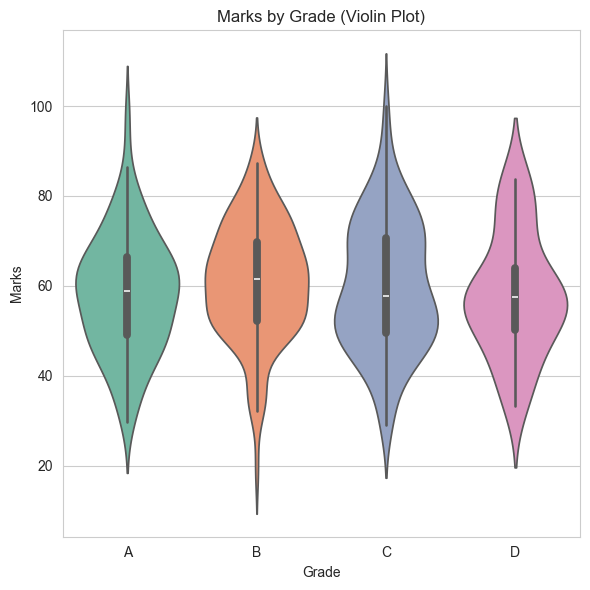

In [22]:
plt.figure(figsize=(6, 6))

sns.violinplot(data=df,
               x="grade",
               y="marks",
               palette="Set2",
               order=["A","B","C","D"])

plt.title("Marks by Grade (Violin Plot)")
plt.xlabel("Grade")
plt.ylabel("Marks")
plt.tight_layout()
plt.savefig("violinplot_marks_by_grade.png", dpi=150)
plt.show()

### Plot 3 — Mean Bar Chart with Error Bars


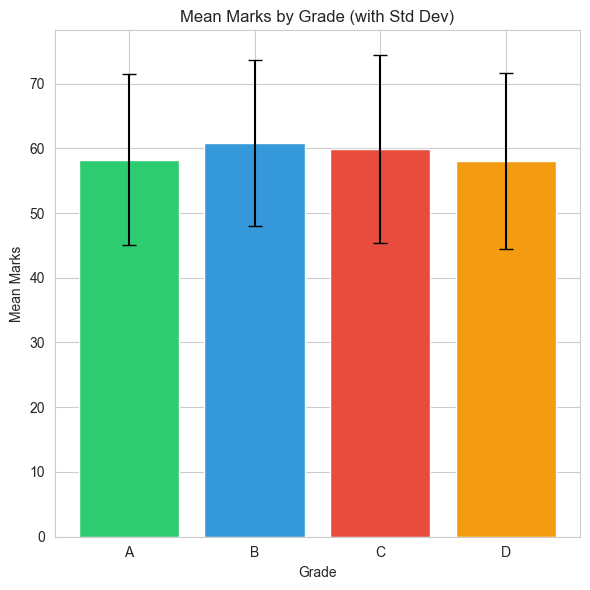

In [23]:
plt.figure(figsize=(6, 6))

grade_stats = df.groupby("grade")["marks"].agg(["mean","std"]).reindex(["A","B","C","D"])

plt.bar(grade_stats.index,
        grade_stats["mean"],
        yerr=grade_stats["std"],
        color=['#2ecc71','#3498db','#e74c3c','#f39c12'],
        edgecolor='white',
        capsize=5)

plt.title("Mean Marks by Grade (with Std Dev)")
plt.xlabel("Grade")
plt.ylabel("Mean Marks")
plt.tight_layout()
plt.savefig("barplot_mean_marks_by_grade.png", dpi=150)
plt.show()